In [4]:
# ==========================================
# CÉLULA 1: SETUP E CARREGAMENTO (AJUSTADO)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [5]:
# Carregando com mapeamento correto
import os

# Define o caminho para a pasta 'data' que está no mesmo nível do seu notebook
data_dir = 'data'

# Carregando com mapeamento correto apontando para a pasta 'data'
accounts = pd.read_csv(os.path.join(data_dir, 'ravenstack_accounts.csv'))
subscriptions = pd.read_csv(os.path.join(data_dir, 'ravenstack_subscriptions.csv'))
feature_usage = pd.read_csv(os.path.join(data_dir, 'ravenstack_feature_usage.csv'))
support_tickets = pd.read_csv(os.path.join(data_dir, 'ravenstack_support_tickets.csv'))
churn_events = pd.read_csv(os.path.join(data_dir, 'ravenstack_churn_events.csv'))

print("✅ Dados carregados com sucesso!")

✅ Dados carregados com sucesso!


In [6]:
# ==========================================
# CÉLULA 2: ANÁLISE QUALITATIVA DO CHURN
# ==========================================
# O que os clientes estão dizendo ao sair?
print("--- Principais Motivos de Cancelamento (Reason Codes) ---")
reason_counts = churn_events['reason_code'].value_counts()
print(reason_counts)

# Mostrar uma prévia do feedback em texto para captar dores reais
print("\n--- Amostra de Feedbacks Reais dos Clientes ---")
print(churn_events['feedback_text'].dropna().head(5))

--- Principais Motivos de Cancelamento (Reason Codes) ---
reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

--- Amostra de Feedbacks Reais dos Clientes ---
0    switched to competitor
2          missing features
3    switched to competitor
4             too expensive
5          missing features
Name: feedback_text, dtype: object


In [7]:
# ==========================================
# CÉLULA 3: IMPACTO FINANCEIRO (MRR)
# ==========================================
churned_ids = churn_events['account_id'].unique()
accounts['status'] = accounts['account_id'].apply(lambda x: 'Churned' if x in churned_ids else 'Active')

# Unindo assinaturas e contas para ver o faturamento
sub_accounts = pd.merge(subscriptions, accounts, on='account_id', how='left')
# Verificar os nomes das colunas de assinaturas
print("Colunas em subscriptions:", subscriptions.columns.tolist())


Colunas em subscriptions: ['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']


In [8]:
mrr_lost = sub_accounts[sub_accounts['status'] == 'Churned']['mrr_amount'].sum()
mrr_active = sub_accounts[sub_accounts['status'] == 'Active']['mrr_amount'].sum()
churn_rate_revenue = (mrr_lost / (mrr_lost + mrr_active)) * 100

print(f"💰 MRR Ativo: ${mrr_active:,.2f}")
print(f"💔 MRR Perdido (Churn): ${mrr_lost:,.2f}")
print(f"📉 Taxa de Churn de Receita: {churn_rate_revenue:.2f}%")

💰 MRR Ativo: $3,347,765.00
💔 MRR Perdido (Churn): $7,990,982.00
📉 Taxa de Churn de Receita: 70.48%


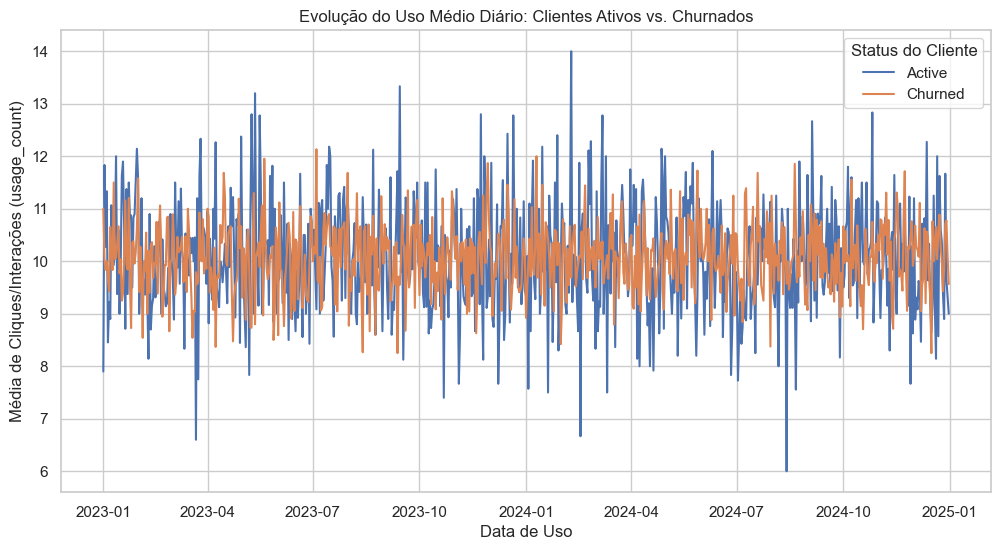

In [9]:
# ==========================================
# CÉLULA 4: O PARADOXO DO PRODUTO (TENDÊNCIA DE USO)
# ==========================================
# Vamos ver se o uso realmente subiu ou se caiu antes do Churn
# 1. Padronizar as colunas da tabela de uso para minúsculas
feature_usage.columns = feature_usage.columns.str.lower()

# 2. Garantir que a coluna de data esteja no formato correto
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

# 3. Agrupar uso diário por assinatura usando 'usage_count'
daily_use = feature_usage.groupby(['subscription_id', 'usage_date'])['usage_count'].sum().reset_index()

# 4. Cruzando com o status da conta (sub_accounts já foi criado na célula anterior)
daily_use = pd.merge(daily_use, sub_accounts[['subscription_id', 'status']], on='subscription_id', how='left')

# 5. Gerar o gráfico de linha temporal para comparar o uso de Ativos vs. Churnados
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_use, x='usage_date', y='usage_count', hue='status', estimator='mean', errorbar=None)
plt.title('Evolução do Uso Médio Diário: Clientes Ativos vs. Churnados')
plt.ylabel('Média de Cliques/Interações (usage_count)')
plt.xlabel('Data de Uso')
plt.legend(title='Status do Cliente')
plt.show()


In [10]:
# ==========================================
# CÉLULA 5: SISTEMA DE ALERTA VERMELHO (MÉTRICA DE RISCO)
# ==========================================
# Criando a lista de clientes ativos em risco com base na queda de uso recente
# Pegando a média de uso dos últimos 7 dias de dados de cada um

# 1. Definir data maxima e filtro de 7 dias
max_date = feature_usage['usage_date'].max()
recent_usage = feature_usage[feature_usage['usage_date'] >= (max_date - pd.Timedelta(days=7))]

# 2. Agrupar uso medio diario e media de erros
recent_agg = recent_usage.groupby('subscription_id')[['usage_count', 'error_count']].mean().reset_index()

# 3. Filtrar contas ativas garantindo colunas existentes
colunas_assinatura = [col for col in ['subscription_id', 'account_id', 'plan_tier', 'mrr_amount'] if col in sub_accounts.columns]
active_risk = sub_accounts[sub_accounts['status'] == 'Active'][colunas_assinatura].copy()

# 4. Cruzar dados
active_risk = pd.merge(active_risk, recent_agg, on='subscription_id', how='inner')

# 5. Definir limites de corte para risco
avg_active_usage = active_risk['usage_count'].mean()
error_threshold = active_risk['error_count'].quantile(0.75)


In [11]:
# 6. Calcular Score de Risco
active_risk['risk_score'] = 0
active_risk.loc[active_risk['usage_count'] < (avg_active_usage * 0.5), 'risk_score'] += 1
active_risk.loc[active_risk['error_count'] > error_threshold, 'risk_score'] += 1

# 7. Filtrar e ordenar contas em risco pelo MRR
lista_resgate = active_risk[active_risk['risk_score'] >= 1].sort_values(by='mrr_amount', ascending=False)

# 8. Definir colunas para exibicao final
colunas_exibicao = [col for col in ['account_id', 'plan_tier', 'mrr_amount', 'usage_count', 'error_count', 'risk_score'] if col in lista_resgate.columns]

# 9. Print dos resultados
print(f"🚨 Encontradas {len(lista_resgate)} contas ativas com sinais de alerta de Churn.")
print("\n--- TOP 10 CONTAS EM RISCO IMEDIATO (Para o time de CS ligar amanhã):")
print(lista_resgate[colunas_exibicao].head(10))

🚨 Encontradas 18 contas ativas com sinais de alerta de Churn.

--- TOP 10 CONTAS EM RISCO IMEDIATO (Para o time de CS ligar amanhã):
   account_id  mrr_amount  usage_count  error_count  risk_score
70   A-fd9422       11542          6.0          4.0           1
28   A-bb2f49        9751         11.0          2.0           1
43   A-068fc6        6965         17.0          2.0           1
23   A-9badbd        5970         19.0          4.0           1
15   A-970c97        2786         15.0          2.0           1
39   A-f9cc74        1470          8.0          2.0           1
20   A-88c6ca         995          4.0          2.0           2
42   A-4e960a         588         16.0          3.0           1
58   A-139c3b         551          7.0          2.0           1
53   A-43a9e3         418         12.0          2.0           1
